<a href="https://colab.research.google.com/github/Indu7777/6thSem-ML-Lab/blob/main/1BM23CS131_LAB4_LOGISTIC_REGRESSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HR EMPLOYEE RETENTION ANALYSIS

Dataset Shape: (14999, 10)

First 5 rows of the dataset:
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3         

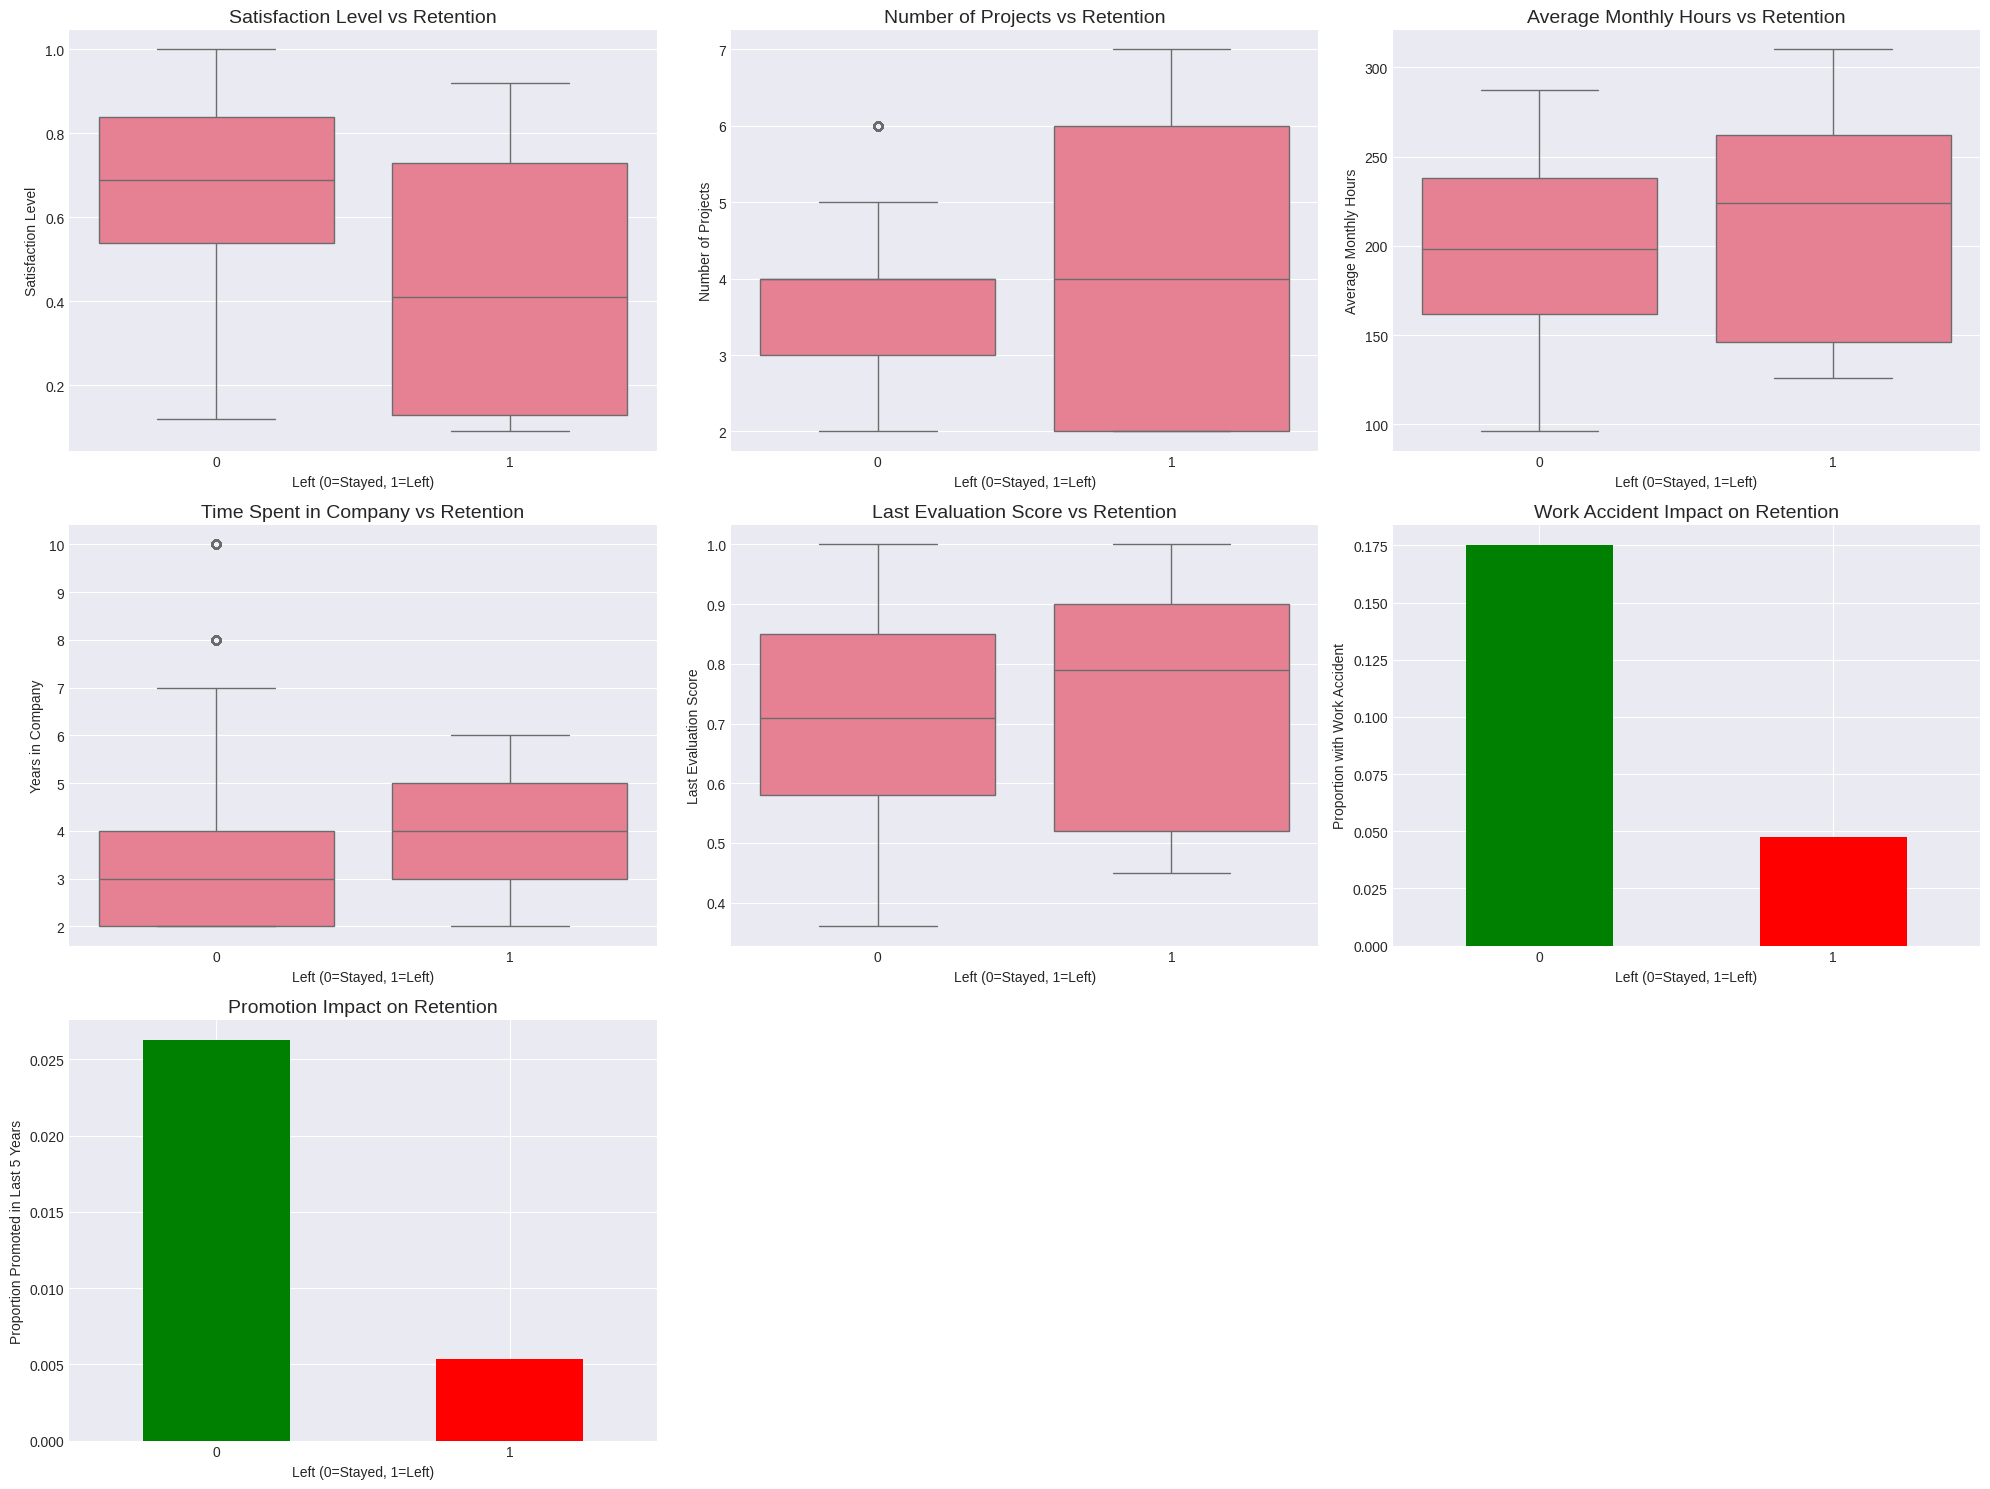


AVERAGE VALUES BY RETENTION STATUS


TypeError: agg function failed [how->mean,dtype->object]

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
print("="*60)
print("HR EMPLOYEE RETENTION ANALYSIS")
print("="*60)

df = pd.read_csv('HR_comma_sep.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"\nFirst 5 rows of the dataset:")
print(df.head())

# Check basic info
print("\n" + "="*60)
print("BASIC DATASET INFORMATION")
print("="*60)
print(f"\nDataset Info:")
print(df.info())

print(f"\nMissing Values:")
print(df.isnull().sum())

print(f"\nBasic Statistics:")
print(df.describe())

print(f"\nTarget Variable Distribution (left):")
print(df['left'].value_counts())
print(f"Percentage who left: {df['left'].mean()*100:.2f}%")
print(f"Percentage who stayed: {(1-df['left'].mean())*100:.2f}%")

# ============================================================================
# STEP 1: EXPLORATORY DATA ANALYSIS - Identify variables impacting retention
# ============================================================================
print("\n" + "="*60)
print("STEP 1: EXPLORATORY DATA ANALYSIS")
print("="*60)

# Create a figure for multiple plots
fig = plt.figure(figsize=(20, 15))

# 1. Satisfaction Level Analysis
ax1 = plt.subplot(3, 3, 1)
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title('Satisfaction Level vs Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Satisfaction Level')

# 2. Number of Projects Analysis
ax2 = plt.subplot(3, 3, 2)
sns.boxplot(x='left', y='number_project', data=df)
plt.title('Number of Projects vs Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Number of Projects')

# 3. Average Monthly Hours Analysis
ax3 = plt.subplot(3, 3, 3)
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.title('Average Monthly Hours vs Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Average Monthly Hours')

# 4. Time Spent in Company Analysis
ax4 = plt.subplot(3, 3, 4)
sns.boxplot(x='left', y='time_spend_company', data=df)
plt.title('Time Spent in Company vs Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Years in Company')

# 5. Last Evaluation Analysis
ax5 = plt.subplot(3, 3, 5)
sns.boxplot(x='left', y='last_evaluation', data=df)
plt.title('Last Evaluation Score vs Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Last Evaluation Score')

# 6. Work Accident Analysis
ax6 = plt.subplot(3, 3, 6)
work_accident_plot = df.groupby('left')['Work_accident'].mean().plot(kind='bar', color=['green', 'red'])
plt.title('Work Accident Impact on Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Proportion with Work Accident')
plt.xticks(rotation=0)

# 7. Promotion Analysis
ax7 = plt.subplot(3, 3, 7)
promotion_plot = df.groupby('left')['promotion_last_5years'].mean().plot(kind='bar', color=['green', 'red'])
plt.title('Promotion Impact on Retention', fontsize=14)
plt.xlabel('Left (0=Stayed, 1=Left)')
plt.ylabel('Proportion Promoted in Last 5 Years')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig('hr_analysis_1.png', dpi=100, bbox_inches='tight')
plt.show()

# Calculate average values for each group
print("\n" + "="*60)
print("AVERAGE VALUES BY RETENTION STATUS")
print("="*60)
grouped = df.groupby('left').mean()
print(grouped)

# ============================================================================
# STEP 2: IMPACT OF SALARY ON RETENTION
# ============================================================================
print("\n" + "="*60)
print("STEP 2: IMPACT OF SALARY ON RETENTION")
print("="*60)

# Create salary vs retention plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart 1: Salary distribution by retention status
salary_left = pd.crosstab(df['salary'], df['left'], normalize='columns') * 100
salary_left.plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Salary Distribution: Stayed vs Left', fontsize=14)
axes[0].set_xlabel('Salary Level')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Left'])
axes[0].tick_params(axis='x', rotation=0)

# Bar chart 2: Retention rate by salary level
salary_retention = df.groupby('salary')['left'].mean() * 100
salary_retention.plot(kind='bar', ax=axes[1], color=['skyblue', 'orange', 'lightgreen'])
axes[1].set_title('Percentage Who Left by Salary Level', fontsize=14)
axes[1].set_xlabel('Salary Level')
axes[1].set_ylabel('Percentage Who Left (%)')
axes[1].tick_params(axis='x', rotation=0)

# Add value labels on bars
for i, v in enumerate(salary_retention):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('hr_salary_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nRetention Rate by Salary Level:")
print(salary_retention)
print("\nObservation: Employees with low salary are more likely to leave.")

# ============================================================================
# STEP 3: IMPACT OF DEPARTMENT ON RETENTION
# ============================================================================
print("\n" + "="*60)
print("STEP 3: IMPACT OF DEPARTMENT ON RETENTION")
print("="*60)

# Create department vs retention plot
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Bar chart 1: Department distribution by retention status
dept_left = pd.crosstab(df['Department'], df['left'], normalize='columns') * 100
dept_left.sort_values(by=1, ascending=False).plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Department Distribution: Stayed vs Left', fontsize=14)
axes[0].set_xlabel('Department')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(['Stayed', 'Left'])
axes[0].tick_params(axis='x', rotation=45)

# Bar chart 2: Retention rate by department
dept_retention = df.groupby('Department')['left'].mean() * 100
dept_retention.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Percentage Who Left by Department', fontsize=14)
axes[1].set_xlabel('Department')
axes[1].set_ylabel('Percentage Who Left (%)')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, (dept, v) in enumerate(dept_retention.sort_values(ascending=False).items()):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('hr_department_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nRetention Rate by Department (sorted by highest turnover):")
print(dept_retention.sort_values(ascending=False))
print("\nObservation: HR, Accounting, Technical, and Support departments have highest turnover.")

# ============================================================================
# STEP 4: ADDITIONAL INSIGHTS - Correlation Analysis
# ============================================================================
print("\n" + "="*60)
print("STEP 4: CORRELATION ANALYSIS")
print("="*60)

# Create correlation matrix for numerical features
numerical_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
                  'average_montly_hours', 'time_spend_company', 'Work_accident',
                  'promotion_last_5years', 'left']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Numerical Features', fontsize=16)
plt.tight_layout()
plt.savefig('hr_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Display correlation with 'left' (target)
print("\nCorrelation with 'left' (target variable):")
corr_with_target = corr_matrix['left'].sort_values(ascending=False)
print(corr_with_target)

# ============================================================================
# STEP 5: BUILD LOGISTIC REGRESSION MODEL
# ============================================================================
print("\n" + "="*60)
print("STEP 5: BUILDING LOGISTIC REGRESSION MODEL")
print("="*60)

# Based on EDA, select important features
selected_features = [
    'satisfaction_level',           # Strong negative correlation
    'number_project',               # U-shaped relationship with turnover
    'average_montly_hours',         # U-shaped relationship
    'time_spend_company',            # Positive correlation with turnover
    'last_evaluation',              # Mixed relationship
    'Work_accident',                # Negative correlation
    'promotion_last_5years'         # Strong negative correlation
]

# Handle categorical variables (salary and department)
df_encoded = pd.get_dummies(df, columns=['salary', 'Department'], drop_first=True)

# Add selected features plus all encoded categorical columns
encoded_cols = [col for col in df_encoded.columns if col.startswith('salary_') or col.startswith('Department_')]
all_features = selected_features + encoded_cols

print(f"\nFeatures used in the model: {len(all_features)} features")
print("Selected features:", selected_features)
print("Encoded categorical features:", encoded_cols)

# Prepare X and y
X = df_encoded[all_features]
y = df_encoded['left']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution:\n{y.value_counts()}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train the logistic regression model
print("\nTraining Logistic Regression model...")
model = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# ============================================================================
# STEP 6: MEASURE MODEL ACCURACY
# ============================================================================
print("\n" + "="*60)
print("STEP 6: MODEL ACCURACY EVALUATION")
print("="*60)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Detailed classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT - TEST SET")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Stayed', 'Left']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Left'],
            yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('hr_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': model.coef_[0]
})
feature_importance = feature_importance.sort_values('coefficient', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE (Coefficients)")
print("="*60)
print("Top 10 features increasing likelihood of leaving:")
print(feature_importance.head(10))
print("\nTop 10 features decreasing likelihood of leaving (retention factors):")
print(feature_importance.tail(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
colors = ['red' if x < 0 else 'green' for x in feature_importance['coefficient'].head(15)]
plt.barh(feature_importance['feature'].head(15), feature_importance['coefficient'].head(15), color=colors)
plt.xlabel('Coefficient Value')
plt.title('Top 15 Features Impacting Employee Turnover', fontsize=16)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('hr_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"""
KEY FINDINGS:
1. Variables with direct impact on retention:
   - satisfaction_level (strongest negative correlation)
   - number_project (U-shaped relationship)
   - average_montly_hours (U-shaped relationship)
   - time_spend_company (positive correlation)
   - promotion_last_5years (strong retention factor)
   - Work_accident (retention factor)
   - salary level (low salary increases turnover)
   - department (HR, Accounting have highest turnover)

2. Salary Impact:
   - Low salary employees: {salary_retention['low']:.1f}% turnover rate
   - Medium salary employees: {salary_retention['medium']:.1f}% turnover rate
   - High salary employees: {salary_retention['high']:.1f}% turnover rate

3. Department Impact:
   - Highest turnover: {dept_retention.idxmax()} ({dept_retention.max():.1f}%)
   - Lowest turnover: {dept_retention.idxmin()} ({dept_retention.min():.1f}%)

4. Model Performance:
   - Training Accuracy: {train_accuracy:.2%}
   - Testing Accuracy: {test_accuracy:.2%}

5. CONCLUSION:
   The logistic regression model achieves {test_accuracy:.2%} accuracy on test data.
   This is {'excellent' if test_accuracy > 0.85 else 'good' if test_accuracy > 0.75 else 'moderate'} performance for employee turnover prediction.
   The model successfully identifies key factors influencing employee retention.
""")